In [12]:
import pandas as pd

# Load the dataset to examine its structure
file_path = 'Cleaned_dataset.csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
data_info = {
    "shape": data.shape,
    "columns": data.columns.tolist(),
    "missing_values": data.isnull().sum().to_dict(),
    "sample_data": data.head().to_dict()
}

data_info

{'shape': (3300, 15),
 'columns': ['Type',
  'Localisation',
  'Latitude',
  'Longitude',
  'Title',
  'Price in DH',
  'Tags',
  'Tags_length',
  'Area in m²',
  'Rooms',
  'Bedrooms',
  'Bathrooms',
  'Condition',
  'Floor',
  'House Age in ans'],
 'missing_values': {'Type': 0,
  'Localisation': 0,
  'Latitude': 0,
  'Longitude': 0,
  'Title': 0,
  'Price in DH': 0,
  'Tags': 0,
  'Tags_length': 0,
  'Area in m²': 0,
  'Rooms': 0,
  'Bedrooms': 0,
  'Bathrooms': 0,
  'Condition': 0,
  'Floor': 0,
  'House Age in ans': 0},
 'sample_data': {'Type': {0: 'Appartements Casablanca',
   1: 'Appartements Casablanca',
   2: 'Appartements Casablanca',
   3: 'Appartements Casablanca',
   4: 'Appartements Casablanca'},
  'Localisation': {0: 'Casablanca Finance City à Casablanca',
   1: 'Anfa à Casablanca',
   2: 'La Gironde à Casablanca',
   3: 'Bourgogne Ouest à Casablanca',
   4: 'Les princesses à Casablanca'},
  'Latitude': {0: 33.56170473792227,
   1: 33.56170473792227,
   2: 33.561704737922

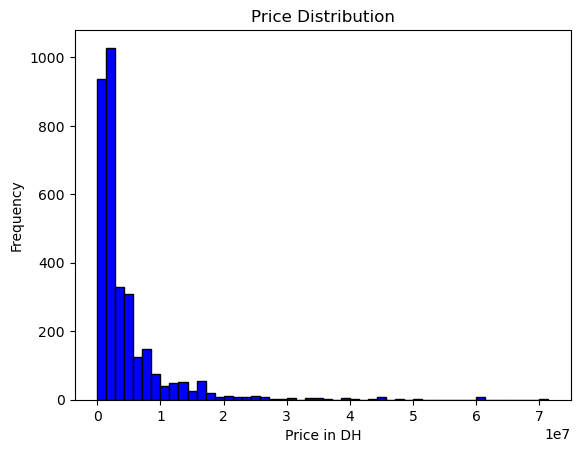

In [13]:
import matplotlib.pyplot as plt

plt.hist(data['Price in DH'], bins=50, color='blue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price in DH')
plt.ylabel('Frequency')
plt.show()


In [14]:
# Define price thresholds
lower_bound = 50000
upper_bound = 10000000

# Filter data
filtered_data = data[(data['Price in DH'] >= lower_bound) & 
                             (data['Price in DH'] <= upper_bound)]

print(f"Original dataset size: {len(data)}")
print(f"Filtered dataset size: {len(filtered_data)}")

Original dataset size: 3300
Filtered dataset size: 2937


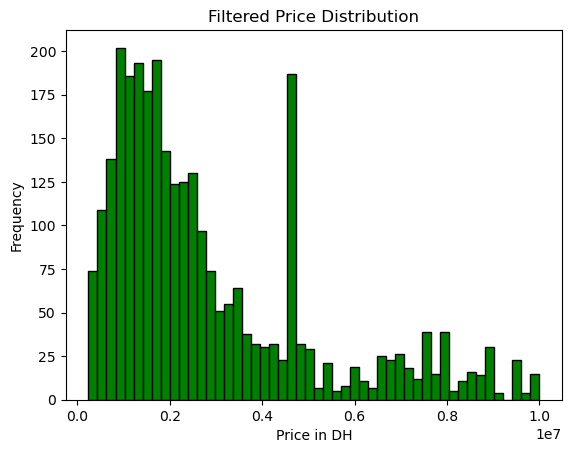

In [15]:
plt.hist(filtered_data['Price in DH'], bins=50, color='green', edgecolor='black')
plt.title('Filtered Price Distribution')
plt.xlabel('Price in DH')
plt.ylabel('Frequency')
plt.show()

In [16]:
data = filtered_data
data.shape

(2937, 15)

In [17]:
# Display basic information about the dataset
data_info = {
    "shape": data.shape,
    "columns": data.columns.tolist(),
    "missing_values": data.isnull().sum().to_dict(),
    "sample_data": data.head().to_dict()
}

data_info

{'shape': (2937, 15),
 'columns': ['Type',
  'Localisation',
  'Latitude',
  'Longitude',
  'Title',
  'Price in DH',
  'Tags',
  'Tags_length',
  'Area in m²',
  'Rooms',
  'Bedrooms',
  'Bathrooms',
  'Condition',
  'Floor',
  'House Age in ans'],
 'missing_values': {'Type': 0,
  'Localisation': 0,
  'Latitude': 0,
  'Longitude': 0,
  'Title': 0,
  'Price in DH': 0,
  'Tags': 0,
  'Tags_length': 0,
  'Area in m²': 0,
  'Rooms': 0,
  'Bedrooms': 0,
  'Bathrooms': 0,
  'Condition': 0,
  'Floor': 0,
  'House Age in ans': 0},
 'sample_data': {'Type': {1: 'Appartements Casablanca',
   2: 'Appartements Casablanca',
   3: 'Appartements Casablanca',
   4: 'Appartements Casablanca',
   5: 'Appartements Casablanca'},
  'Localisation': {1: 'Anfa à Casablanca',
   2: 'La Gironde à Casablanca',
   3: 'Bourgogne Ouest à Casablanca',
   4: 'Les princesses à Casablanca',
   5: 'Bourgogne Ouest à Casablanca'},
  'Latitude': {1: 33.56170473792227,
   2: 33.56170473792227,
   3: 33.56170473792227,
   4

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop unnecessary columns
columns_to_drop = ['Title', 'Tags', 'Tags_length', 'Localisation']
data_cleaned = data.drop(columns=columns_to_drop)

# Encode categorical variables
categorical_columns = ['Type', 'Condition']
label_encoders = {}
for col in categorical_columns:
    encoder = LabelEncoder()
    data_cleaned[col] = encoder.fit_transform(data_cleaned[col])
    label_encoders[col] = encoder

# Separate features and target
X = data_cleaned.drop(columns=['Price in DH'])
y = data_cleaned['Price in DH']

# Normalize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

# Summary of processed data
processed_data_info = {
    "X_train_shape": X_train.shape,
    "X_test_shape": X_test.shape,
    "y_train_shape": y_train.shape,
    "y_test_shape": y_test.shape,
    "feature_names": X.columns.tolist()
}

processed_data_info

{'X_train_shape': (2643, 10),
 'X_test_shape': (294, 10),
 'y_train_shape': (2643,),
 'y_test_shape': (294,),
 'feature_names': ['Type',
  'Latitude',
  'Longitude',
  'Area in m²',
  'Rooms',
  'Bedrooms',
  'Bathrooms',
  'Condition',
  'Floor',
  'House Age in ans']}

In [19]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Define the FFNN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer with 64 neurons
    Dense(32, activation='relu'),  # Hidden layer with 32 neurons
    Dense(1)  # Output layer (single value prediction)
])

# Compile the model
model.compile(
    optimizer='sgd',  # Stochastic Gradient Descent
    loss='mean_squared_error',  # Mean Squared Error
    metrics=['mae']  # Mean Absolute Error for evaluation
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.1,  # Use 10% of training data for validation
    epochs=50,
    batch_size=32,
    verbose=1
)

2025-01-08 23:01:11.151605: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 23:01:11.156373: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 23:01:11.173013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736373671.199348  227796 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736373671.205574  227796 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-08 23:01:11.235751: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1502548400420015105158152192.0000 - mae: 8801477459968.0000 - val_loss: 394479262531839466668032.0000 - val_mae: 628075855872.0000
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 222504284743512931434496.0000 - mae: 452948000768.0000 - val_loss: 19051759899450317733888.0000 - val_mae: 138028105728.0000
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10746077351465573154816.0000 - mae: 99541450752.0000 - val_loss: 920122488199973961728.0000 - val_mae: 30333523968.0000
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 518990247089804410880.0000 - mae: 21875548160.0000 - val_loss: 44437769589218082816.0000 - val_mae: 6666165760.0000
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25064728750549106688.0000 - mae: 4807412736.0000 - val_loss: 2146008790590291968.0000 - val_mae: 1464924416.0000
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1210482862466269184.0000 - mae: 1056480064.0000

In [20]:
# Evaluate the model on test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_loss}, Test MAE: {test_mae}")

Test MSE: 5706379427840.0, Test MAE: 1861098.625


In [21]:
import numpy as np

# Example input (replace with your data)
sample_input = np.array([[1, 34.5, -118.5, 150, 3, 2, 1, 0, 2, 5]])  # Example row
sample_input_scaled = scaler.transform(sample_input)

# Predict
predicted_price = model.predict(sample_input_scaled)
print(f"Predicted Price: {predicted_price[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Price: 2836076.0


/home/am44/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [33]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


/home/am44/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 12934312886272.0000 - mae: 2839074.5000 - val_loss: 13058186412032.0000 - val_mae: 2802162.7500
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12720173744128.0000 - mae: 2830592.2500 - val_loss: 13045251178496.0000 - val_mae: 2800701.0000
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13246727716864.0000 - mae: 2859315.0000 - val_loss: 12970649190400.0000 - val_mae: 2792567.2500
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12350926094336.0000 - mae: 2768627.2500 - val_loss: 12733190766592.0000 - val_mae: 2766829.5000
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12990610931712.0000 - mae: 2881860.0000 - val_loss: 12213899231232.0000 - val_mae: 2709498.5000
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11679896174592.0000 - mae: 2686810.5000 - val_loss: 11280681271296.0000 - val_mae: 2602712.0000
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10909314449408.0000 - m

In [35]:
# Evaluate the model on test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_loss}, Test MAE: {test_mae}")

Test MSE: 2529060192256.0, Test MAE: 1029051.5625


In [37]:
# Example input (replace with your data)
sample_input = np.array([[1, 34.5, -118.5, 150, 3, 2, 1, 0, 2, 5]])  # Example row
sample_input_scaled = scaler.transform(sample_input)

# Predict
predicted_price = model.predict(sample_input_scaled)
print(f"Predicted Price: {predicted_price[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Price: 1166796672.0


/home/am44/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
